# Grouping Feature Ablation: Primary-Only 排序

这个 notebook 读取 `experiment_metric_summary/grouping_feature_ablation_primary_only_sorted.csv`，单独查看 5-feature 固定分组、之前大特征/全特征固定分组、以及 soft-router 动态 actor 选择的 Primary-Only 对比结果。

排序依据：`primary_rank` 越小越好。

In [18]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

repo_dir = Path.cwd()
if repo_dir.name == "notebooks":
    repo_dir = repo_dir.parent

csv_path = repo_dir / "experiment_metric_summary" / "grouping_feature_ablation_primary_only_sorted.csv"
df = pd.read_csv(csv_path)

df["primary_rank"] = df["primary_rank"].astype(int)
df["overall_rank"] = df["overall_rank"].astype(int)

display(Markdown(f"Loaded `{csv_path}` with **{len(df)}** rows."))

Loaded `/home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/grouping_feature_ablation_primary_only_sorted.csv` with **17** rows.

## 总表

包含 5f compact、之前较大/全特征固定分组、以及 dynamic soft-router 结果。

In [19]:
show_cols = [
    "primary_rank",
    "primary_rank_score",
    "overall_rank",
    "architecture",
    "grouping_method_short",
    "grouping_feature_set_short",
    "feature_group",
    "primary_load_cv_rmse_pct",
    "primary_abs_nmbe_pct",
    "primary_comfort_exceedance_pct",
    "test_reward_sum",
    "experiment",
]

display(
    df[show_cols]
    .sort_values(["primary_rank", "primary_rank_score"])
    .style
    .background_gradient(subset=["primary_rank", "primary_rank_score", "primary_load_cv_rmse_pct", "primary_abs_nmbe_pct", "primary_comfort_exceedance_pct"], cmap="RdYlGn_r")
    .format({
        "primary_rank_score": "{:.4f}",
        "primary_load_cv_rmse_pct": "{:.4f}",
        "primary_abs_nmbe_pct": "{:.4f}",
        "primary_comfort_exceedance_pct": "{:.4f}",
        "test_reward_sum": "{:.2f}",
    })
)

,primary_rank,primary_rank_score,overall_rank,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
0,5,10.5000,22,PowerNet global,agglomerative,capacity_load_5f,5f compact,50.7454,0.0322,20.0595,-5220.98,mappo_grouped_powernet_global_agglomerative_capacity_load_5f_vt_500_final
1,7,10.7500,14,TarMAC hybrid,gmm,static_operational,previous larger/full,49.1514,0.7687,22.4286,-5927.63,mappo_grouped_tarmac_hybrid_gmm_static_operational_vt_500_final
2,8,11.3333,21,TarMAC hybrid,agglomerative,capacity_load_5f,5f compact,49.2795,2.3189,22.3810,-5894.96,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_final
3,10,13.0833,17,TarMAC hybrid,kmeans,capacity_load_5f,5f compact,51.5607,2.5278,17.3333,-4714.75,mappo_grouped_tarmac_hybrid_kmeans_capacity_load_5f_linear_vt_500_final
4,11,13.6667,7,PowerNet global,kmeans,capacity_load_5f,5f compact,49.6914,3.7919,19.5833,-5119.53,mappo_grouped_powernet_global_kmeans_capacity_load_5f_vt_500_final
5,13,14.9167,12,TarMAC hybrid,agglomerative,static_operational,previous larger/full,48.9323,2.3356,25.6131,-6770.30,mappo_grouped_tarmac_hybrid_agglomerative_static_operational_vt_500_final
6,16,16.2500,11,TarMAC soft-router,soft_router,dynamic_router,dynamic soft-router,47.6043,4.3058,24.6429,-6890.70,mappo_grouped_tarmac_soft_router_vt_500_final_sharp_temperature_0.5_warmup_50
7,17,16.4167,8,PowerNet global,kmeans,static_extended,previous larger/full,53.2467,0.9472,21.2321,-5689.66,mappo_grouped_powernet_global_kmeans_static_extended_vt_500_final
8,20,18.0000,27,TarMAC hybrid,gmm,capacity_load_5f,5f compact,53.0838,0.9417,23.7500,-6114.93,mappo_grouped_tarmac_hybrid_gmm_capacity_load_5f_linear_vt_500_final
9,21,19.9167,31,TarMAC hybrid,kmeans,operational_profile,previous larger/full,55.9836,0.5487,24.5000,-6589.70,mappo_grouped_tarmac_hybrid_kmeans_operational_profile_vt_500_final


## 只看 5-feature compact

5f 特征：`bes_capacity_kwh`, `hvac_total_kw`, `heating_mean`, `nsl_mean`, `comfort_lower_excess_mean`。

In [20]:
df_5f = df[df["feature_group"] == "5f compact"].copy()
display(
    df_5f[show_cols]
    .sort_values(["primary_rank", "primary_rank_score"])
    .style
    .background_gradient(subset=["primary_rank", "primary_rank_score", "primary_load_cv_rmse_pct", "primary_abs_nmbe_pct", "primary_comfort_exceedance_pct"], cmap="RdYlGn_r")
    .format({
        "primary_rank_score": "{:.4f}",
        "primary_load_cv_rmse_pct": "{:.4f}",
        "primary_abs_nmbe_pct": "{:.4f}",
        "primary_comfort_exceedance_pct": "{:.4f}",
        "test_reward_sum": "{:.2f}",
    })
)

,primary_rank,primary_rank_score,overall_rank,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
0,5,10.5000,22,PowerNet global,agglomerative,capacity_load_5f,5f compact,50.7454,0.0322,20.0595,-5220.98,mappo_grouped_powernet_global_agglomerative_capacity_load_5f_vt_500_final
2,8,11.3333,21,TarMAC hybrid,agglomerative,capacity_load_5f,5f compact,49.2795,2.3189,22.3810,-5894.96,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_final
3,10,13.0833,17,TarMAC hybrid,kmeans,capacity_load_5f,5f compact,51.5607,2.5278,17.3333,-4714.75,mappo_grouped_tarmac_hybrid_kmeans_capacity_load_5f_linear_vt_500_final
4,11,13.6667,7,PowerNet global,kmeans,capacity_load_5f,5f compact,49.6914,3.7919,19.5833,-5119.53,mappo_grouped_powernet_global_kmeans_capacity_load_5f_vt_500_final
8,20,18.0000,27,TarMAC hybrid,gmm,capacity_load_5f,5f compact,53.0838,0.9417,23.7500,-6114.93,mappo_grouped_tarmac_hybrid_gmm_capacity_load_5f_linear_vt_500_final
14,30,24.7500,25,PowerNet global,gmm,capacity_load_5f,5f compact,52.6427,4.9400,23.2440,-7807.21,mappo_grouped_powernet_global_gmm_capacity_load_5f_vt_500_final


## 之前的大特征/全特征分组

包含：`static_extended`, `operational_profile`, `static_operational`。

In [21]:
df_full = df[df["feature_group"] == "previous larger/full"].copy()
display(
    df_full[show_cols]
    .sort_values(["primary_rank", "primary_rank_score"])
    .style
    .background_gradient(subset=["primary_rank", "primary_rank_score", "primary_load_cv_rmse_pct", "primary_abs_nmbe_pct", "primary_comfort_exceedance_pct"], cmap="RdYlGn_r")
    .format({
        "primary_rank_score": "{:.4f}",
        "primary_load_cv_rmse_pct": "{:.4f}",
        "primary_abs_nmbe_pct": "{:.4f}",
        "primary_comfort_exceedance_pct": "{:.4f}",
        "test_reward_sum": "{:.2f}",
    })
)

,primary_rank,primary_rank_score,overall_rank,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
1,7,10.7500,14,TarMAC hybrid,gmm,static_operational,previous larger/full,49.1514,0.7687,22.4286,-5927.63,mappo_grouped_tarmac_hybrid_gmm_static_operational_vt_500_final
5,13,14.9167,12,TarMAC hybrid,agglomerative,static_operational,previous larger/full,48.9323,2.3356,25.6131,-6770.30,mappo_grouped_tarmac_hybrid_agglomerative_static_operational_vt_500_final
7,17,16.4167,8,PowerNet global,kmeans,static_extended,previous larger/full,53.2467,0.9472,21.2321,-5689.66,mappo_grouped_powernet_global_kmeans_static_extended_vt_500_final
9,21,19.9167,31,TarMAC hybrid,kmeans,operational_profile,previous larger/full,55.9836,0.5487,24.5000,-6589.70,mappo_grouped_tarmac_hybrid_kmeans_operational_profile_vt_500_final
10,22,21.1667,19,TarMAC hybrid,kmeans,static_extended,previous larger/full,50.6258,3.7907,28.7381,-8108.63,mappo_grouped_tarmac_hybrid_kmeans_static_extended_vt_500_final
12,26,22.6667,26,PowerNet global,gmm,static_operational,previous larger/full,47.6097,12.5494,36.3452,-13682.25,mappo_grouped_powernet_global_gmm_static_operational_vt_500_final
15,31,26.3333,34,PowerNet global,agglomerative,static_operational,previous larger/full,58.8911,2.8959,39.4464,-11970.85,mappo_grouped_powernet_global_agglomerative_static_operational_vt_500_final
16,33,27.1667,32,PowerNet global,kmeans,operational_profile,previous larger/full,53.3941,3.7482,31.3571,-8419.44,mappo_grouped_powernet_global_kmeans_operational_profile_vt_500_final


## Soft-router 动态 actor 选择

这些结果来自 `mappo_grouped_tarmac_soft_router`，不是训练前固定楼宇分组，而是训练/运行时由 router 根据状态对 actor 进行 soft selection。

In [22]:
df_router = df[df["feature_group"] == "dynamic soft-router"].copy()
display(
    df_router[show_cols]
    .sort_values(["primary_rank", "primary_rank_score"])
    .style
    .background_gradient(subset=["primary_rank", "primary_rank_score", "primary_load_cv_rmse_pct", "primary_abs_nmbe_pct", "primary_comfort_exceedance_pct"], cmap="RdYlGn_r")
    .format({
        "primary_rank_score": "{:.4f}",
        "primary_load_cv_rmse_pct": "{:.4f}",
        "primary_abs_nmbe_pct": "{:.4f}",
        "primary_comfort_exceedance_pct": "{:.4f}",
        "test_reward_sum": "{:.2f}",
    })
)

,primary_rank,primary_rank_score,overall_rank,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
6,16,16.2500,11,TarMAC soft-router,soft_router,dynamic_router,dynamic soft-router,47.6043,4.3058,24.6429,-6890.70,mappo_grouped_tarmac_soft_router_vt_500_final_sharp_temperature_0.5_warmup_50
11,23,21.3333,20,TarMAC soft-router,soft_router,dynamic_router,dynamic soft-router,52.5414,5.7213,21.8869,-6535.06,mappo_grouped_tarmac_soft_router_vt_500_final_stable_temperature_1_warmup_100
13,28,24.0833,23,TarMAC soft-router,soft_router,dynamic_router,dynamic soft-router,49.6939,7.8848,31.4881,-10883.35,mappo_grouped_tarmac_soft_router_vt_500_final_balanced_temperature0.7_warmup50


## 按架构和分组方法汇总

这里看每种组合的最好 `primary_rank` 和平均指标。

In [23]:
summary = (
    df.groupby(["architecture", "grouping_method_short", "grouping_feature_set_short", "feature_group"], as_index=False)
    .agg(
        best_primary_rank=("primary_rank", "min"),
        mean_primary_rank_score=("primary_rank_score", "mean"),
        mean_cv_rmse=("primary_load_cv_rmse_pct", "mean"),
        mean_abs_nmbe=("primary_abs_nmbe_pct", "mean"),
        mean_comfort=("primary_comfort_exceedance_pct", "mean"),
        mean_reward=("test_reward_sum", "mean"),
    )
    .sort_values(["best_primary_rank", "mean_primary_rank_score"])
)

display(
    summary.style
    .background_gradient(subset=["best_primary_rank", "mean_primary_rank_score", "mean_cv_rmse", "mean_abs_nmbe", "mean_comfort"], cmap="RdYlGn_r")
    .format({
        "mean_primary_rank_score": "{:.4f}",
        "mean_cv_rmse": "{:.4f}",
        "mean_abs_nmbe": "{:.4f}",
        "mean_comfort": "{:.4f}",
        "mean_reward": "{:.2f}",
    })
)

,architecture,grouping_method_short,grouping_feature_set_short,feature_group,best_primary_rank,mean_primary_rank_score,mean_cv_rmse,mean_abs_nmbe,mean_comfort,mean_reward
0,PowerNet global,agglomerative,capacity_load_5f,5f compact,5,10.5000,50.7454,0.0322,20.0595,-5220.98
10,TarMAC hybrid,gmm,static_operational,previous larger/full,7,10.7500,49.1514,0.7687,22.4286,-5927.63
7,TarMAC hybrid,agglomerative,capacity_load_5f,5f compact,8,11.3333,49.2795,2.3189,22.3810,-5894.96
11,TarMAC hybrid,kmeans,capacity_load_5f,5f compact,10,13.0833,51.5607,2.5278,17.3333,-4714.75
4,PowerNet global,kmeans,capacity_load_5f,5f compact,11,13.6667,49.6914,3.7919,19.5833,-5119.53
8,TarMAC hybrid,agglomerative,static_operational,previous larger/full,13,14.9167,48.9323,2.3356,25.6131,-6770.30
14,TarMAC soft-router,soft_router,dynamic_router,dynamic soft-router,16,20.5555,49.9465,5.9706,26.0060,-8103.04
6,PowerNet global,kmeans,static_extended,previous larger/full,17,16.4167,53.2467,0.9472,21.2321,-5689.66
9,TarMAC hybrid,gmm,capacity_load_5f,5f compact,20,18.0000,53.0838,0.9417,23.7500,-6114.93
12,TarMAC hybrid,kmeans,operational_profile,previous larger/full,21,19.9167,55.9836,0.5487,24.5000,-6589.70


## 图：Primary rank score

`primary_rank_score` 越低越好。

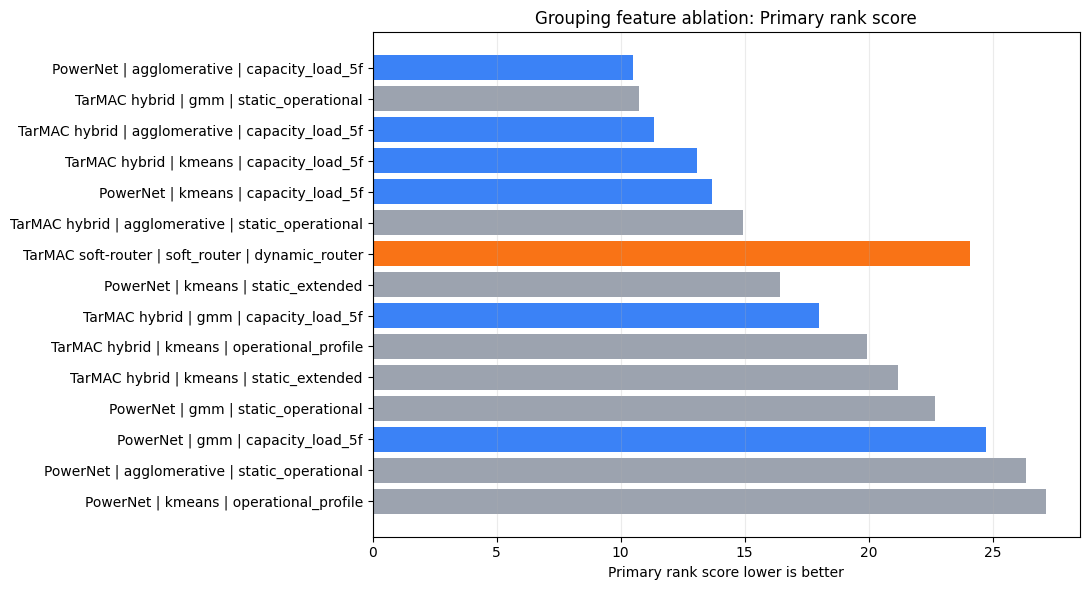

In [24]:
plot_df = df.sort_values("primary_rank_score", ascending=True).copy()
plot_df["label"] = (
    plot_df["architecture"].str.replace(" global", "", regex=False)
    + " | " + plot_df["grouping_method_short"]
    + " | " + plot_df["grouping_feature_set_short"]
)
colors = plot_df["feature_group"].map({"5f compact": "#3b82f6", "previous larger/full": "#9ca3af", "dynamic soft-router": "#f97316"}).fillna("#6b7280")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(plot_df["label"], plot_df["primary_rank_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Primary rank score lower is better")
ax.set_title("Grouping feature ablation: Primary rank score")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 图：CV-RMSE vs Comfort

横轴是 load tracking CV-RMSE，纵轴是 comfort exceedance，两个都越低越好。

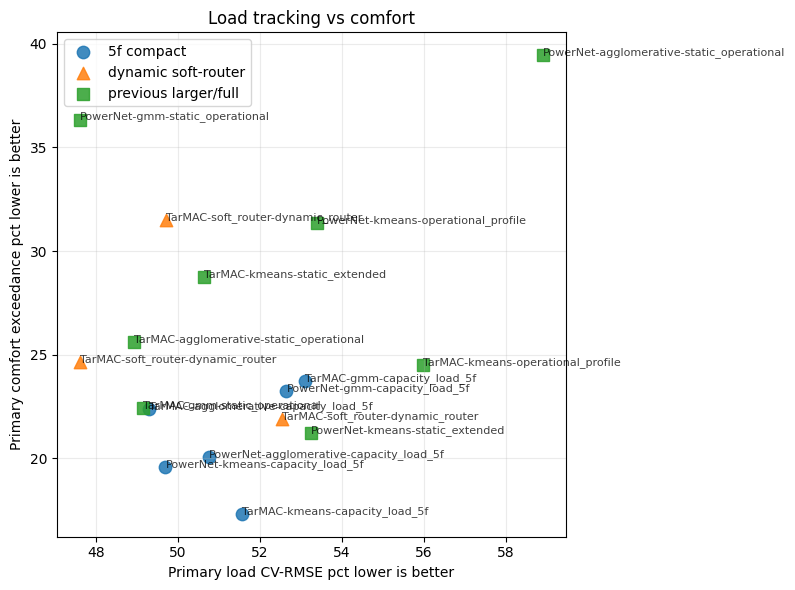

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
marker_map = {"5f compact": "o", "previous larger/full": "s", "dynamic soft-router": "^"}
for feature_group, group_df in df.groupby("feature_group"):
    marker = marker_map.get(feature_group, "x")
    ax.scatter(
        group_df["primary_load_cv_rmse_pct"],
        group_df["primary_comfort_exceedance_pct"],
        label=feature_group,
        marker=marker,
        s=80,
        alpha=0.85,
    )

for _, row in df.iterrows():
    label = f"{row['architecture'].split()[0]}-{row['grouping_method_short']}-{row['grouping_feature_set_short']}"
    ax.annotate(label, (row["primary_load_cv_rmse_pct"], row["primary_comfort_exceedance_pct"]), fontsize=8, alpha=0.75)

ax.set_xlabel("Primary load CV-RMSE pct lower is better")
ax.set_ylabel("Primary comfort exceedance pct lower is better")
ax.set_title("Load tracking vs comfort")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 快速结论辅助

下面自动列出最好的 5 个结果。

In [26]:
top = df.sort_values(["primary_rank", "primary_rank_score"]).head(5)
display(top[[
    "primary_rank",
    "architecture",
    "grouping_method_short",
    "grouping_feature_set_short",
    "primary_load_cv_rmse_pct",
    "primary_abs_nmbe_pct",
    "primary_comfort_exceedance_pct",
    "test_reward_sum",
    "experiment",
]])

,primary_rank,architecture,grouping_method_short,grouping_feature_set_short,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
0,5,PowerNet global,agglomerative,capacity_load_5f,50.7454,0.0322,20.0595,-5220.9771,mappo_grouped_powernet_global_agglomerative_capacity_load_5f_vt_500_final
1,7,TarMAC hybrid,gmm,static_operational,49.1514,0.7687,22.4286,-5927.6258,mappo_grouped_tarmac_hybrid_gmm_static_operational_vt_500_final
2,8,TarMAC hybrid,agglomerative,capacity_load_5f,49.2795,2.3189,22.3810,-5894.9570,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_final
3,10,TarMAC hybrid,kmeans,capacity_load_5f,51.5607,2.5278,17.3333,-4714.7458,mappo_grouped_tarmac_hybrid_kmeans_capacity_load_5f_linear_vt_500_final
4,11,PowerNet global,kmeans,capacity_load_5f,49.6914,3.7919,19.5833,-5119.5337,mappo_grouped_powernet_global_kmeans_capacity_load_5f_vt_500_final
